In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_absolute_error, mean_squared_error

In [13]:
# Load dataset
df = pd.read_csv('AirPassengers.csv')

In [15]:
df['Month'] = pd.to_datetime(df['Month'])

In [17]:
df.set_index('Month', inplace=True)

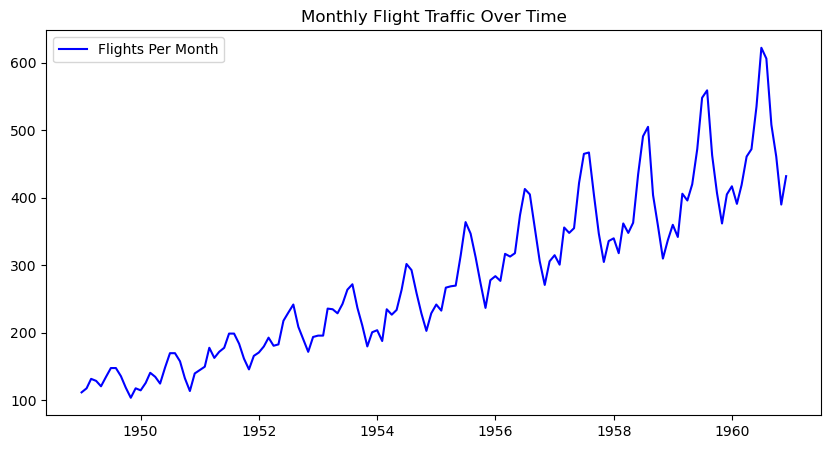

In [19]:
# Plot flight frequency over time
plt.figure(figsize=(10, 5))
plt.plot(df, label="Flights Per Month", color='blue')
plt.title("Monthly Flight Traffic Over Time")
plt.legend()
plt.show()

In [ ]:
help(ARIMA)

In [25]:
# Fit ARIMA model
model = ARIMA(df, order=(2,1,1), seasonal_order=(0,1,0,12))  # Adjust order as needed
model_fit = model.fit()
print(model_fit.summary())

C:\Users\rmuzz\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
C:\Users\rmuzz\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
C:\Users\rmuzz\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
C:\Users\rmuzz\anaconda3\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
C:\Users\rmuzz\anaconda3\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:978: UserWarning: Non-invertible starting MA param

                                     SARIMAX Results                                     
Dep. Variable:                       #Passengers   No. Observations:                  144
Model:             ARIMA(2, 1, 1)x(0, 1, [], 12)   Log Likelihood                -504.923
Date:                           Wed, 09 Apr 2025   AIC                           1017.847
Time:                                   13:56:11   BIC                           1029.348
Sample:                               01-01-1949   HQIC                          1022.520
                                    - 12-01-1960                                         
Covariance Type:                             opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.5959      0.085      6.987      0.000       0.429       0.763
ar.L2          0.2143      0.091      2.343

In [31]:
# Forecast next 12 months
forecast = model_fit.forecast(steps=12)
print("Next 12 months forecast:", forecast)

Next 12 months forecast: 1961-01-01    445.635554
1961-02-01    420.395971
1961-03-01    449.199618
1961-04-01    491.841498
1961-05-01    503.396236
1961-06-01    566.864377
1961-07-01    654.262238
1961-08-01    638.599659
1961-09-01    540.886001
1961-10-01    494.128951
1961-11-01    423.335096
1961-12-01    465.510009
Freq: MS, Name: predicted_mean, dtype: float64


In [33]:
# Evaluate model
y_true = df.iloc[-12:]  # Last 12 months actual values
y_pred = model_fit.predict(start=len(df)-12, end=len(df)-1)
mae = mean_absolute_error(y_true, y_pred)
rmse = np.sqrt(mean_squared_error(y_true, y_pred))

print(f"MAE: {mae}, RMSE: {rmse}")

MAE: 14.978101563259136, RMSE: 19.08206067525428


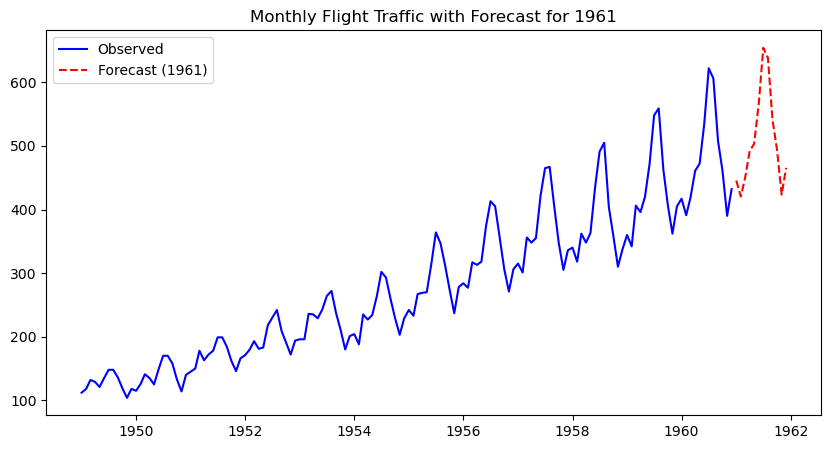

In [37]:
# Create DatetimeIndex for 1961 (next 12 months)
last_date = df.index[-1]
forecast_index = pd.date_range(start=last_date + pd.DateOffset(months=1), periods=12, freq='MS')

# Create forecast DataFrame
forecast_df = pd.DataFrame({'Flights': forecast.values}, index=forecast_index)

# Combine original data with forecast
df_with_forecast = pd.concat([df, forecast_df])

# Plot including the forecast
plt.figure(figsize=(10, 5))
plt.plot(df, label='Observed', color='blue')
plt.plot(forecast_df, label='Forecast (1961)', color='red', linestyle='--')
plt.title("Monthly Flight Traffic with Forecast for 1961")
plt.legend()
plt.show()

In [39]:
# Get forecast object with confidence intervals
forecast_obj = model_fit.get_forecast(steps=12)
forecast_mean = forecast_obj.predicted_mean
conf_int = forecast_obj.conf_int()

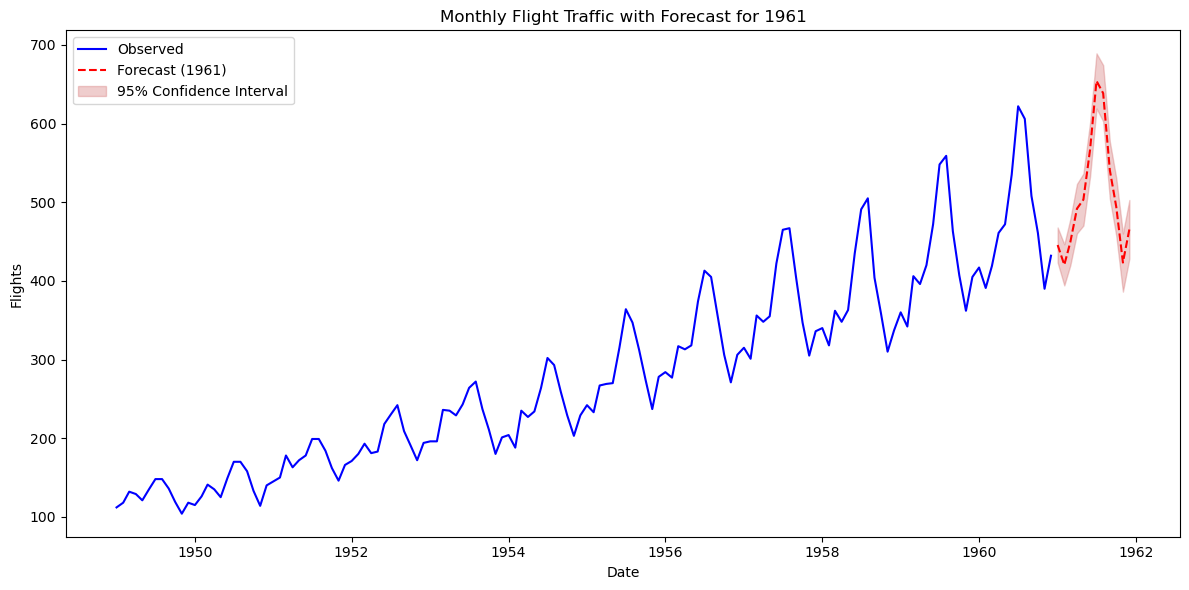

In [45]:
# Create DatetimeIndex for 1961
last_date = df.index[-1]
forecast_index = pd.date_range(start=last_date + pd.DateOffset(months=1), periods=12, freq='MS')

# Assign forecast and confidence intervals to DataFrame
forecast_df = pd.DataFrame({
    'Forecast': forecast_mean.values,
    'Lower CI': conf_int.iloc[:, 0].values,
    'Upper CI': conf_int.iloc[:, 1].values
}, index=forecast_index)

# Combine original data with forecasted values
df_with_forecast = pd.concat([df, forecast_df[['Forecast']].rename(columns={'Forecast': 'Flights'})])

# Plot observed, forecast, and confidence intervals
plt.figure(figsize=(12, 6))
plt.plot(df, label='Observed', color='blue')
plt.plot(forecast_df['Forecast'], label='Forecast (1961)', color='red', linestyle='--')
plt.fill_between(forecast_df.index, forecast_df['Lower CI'], forecast_df['Upper CI'],
                 color='indianred', alpha=0.3, label='95% Confidence Interval')
plt.title("Monthly Flight Traffic with Forecast for 1961")
plt.xlabel("Date")
plt.ylabel("Flights")
plt.legend()
plt.tight_layout()
plt.show()